In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Functions

In [14]:
def calculate_time_weight(delta_t, k=0.33):
    """
    Calculates the logarithmic time weight for a citation or mention.
    """
    return 1 + k * np.log(1 + delta_t)

def get_dataset_index(fi, citations_with_ages, mentions_with_ages, ft=50, ctw=1, mtw=1):
    """
    Calculates the dataset index of a dataset
    """
    # 1. FAIR Term
    term_f = fi / ft
    # 2. Weighted Citations
    ciw = sum(calculate_time_weight(dt) for dt in citations_with_ages)
    term_c = ciw / ctw
    # 3. Weighted Mentions
    miw = sum(calculate_time_weight(dt) for dt in mentions_with_ages)
    term_m = miw / mtw
    # Returning each component separately for visualization
    di = (1/3) * (term_f + term_c + term_m)
    return di, (1/3)*term_f, (1/3)*term_c, (1/3)*term_m

def get_researcher_s_index(dataset_indices):
    """
    Calculates the S-index as the sum of all Dataset Indices (Di).
    """
    return sum(dataset_indices)

## Weight of citations and mentions

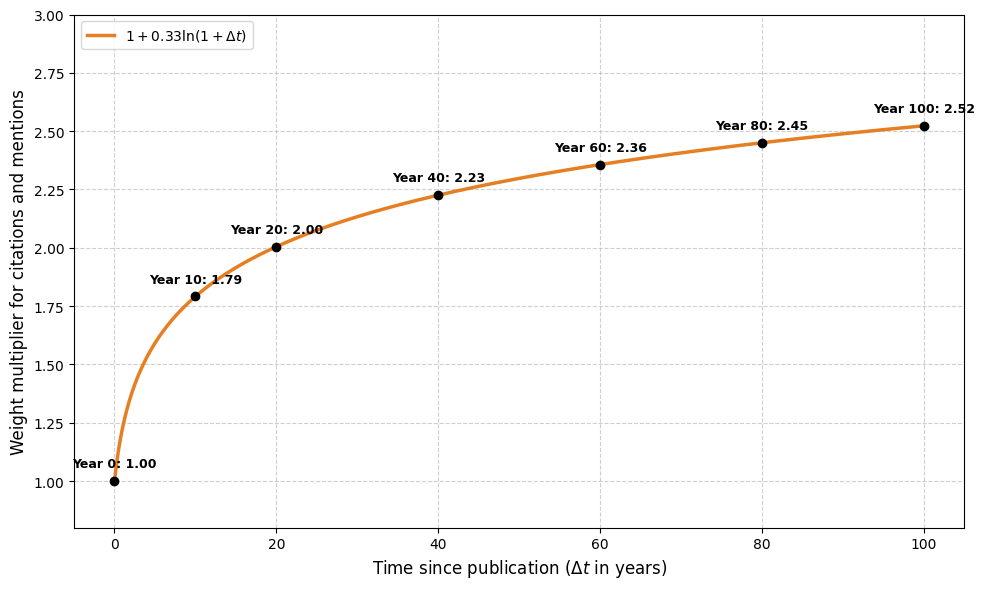

In [22]:
# 1. Generate time range from 0 to 20 years
delta_t_range = np.linspace(0, 100, 400) 
weights = calculate_time_weight(delta_t_range)

# 2. Plotting
plt.figure(figsize=(10, 6))
plt.plot(delta_t_range, weights, label=r'$1 + 0.33 \ln(1 + \Delta t)$', color='#e67e22', linewidth=2.5)

# Highlight specific anchor points
t_points = np.array([0, 10, 20, 40, 60, 80, 100])
w_points = calculate_time_weight(t_points)

plt.scatter(t_points, w_points, color='black', zorder=5)

# Dynamically annotate every point in t_points
for i in range(len(t_points)):
    txt = f'Year {t_points[i]}: {w_points[i]:.2f}'
    plt.annotate(txt, 
                 (t_points[i], w_points[i]), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontweight='bold',
                 fontsize=9)

#plt.title('Time Weight Function Evolution', fontsize=14)
plt.xlabel('Time since publication ($\Delta t$ in years)', fontsize=12)
plt.ylabel('Weight multiplier for citations and mentions', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.8, 3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Contributions of FAIR score, citations, mentions to dataset index

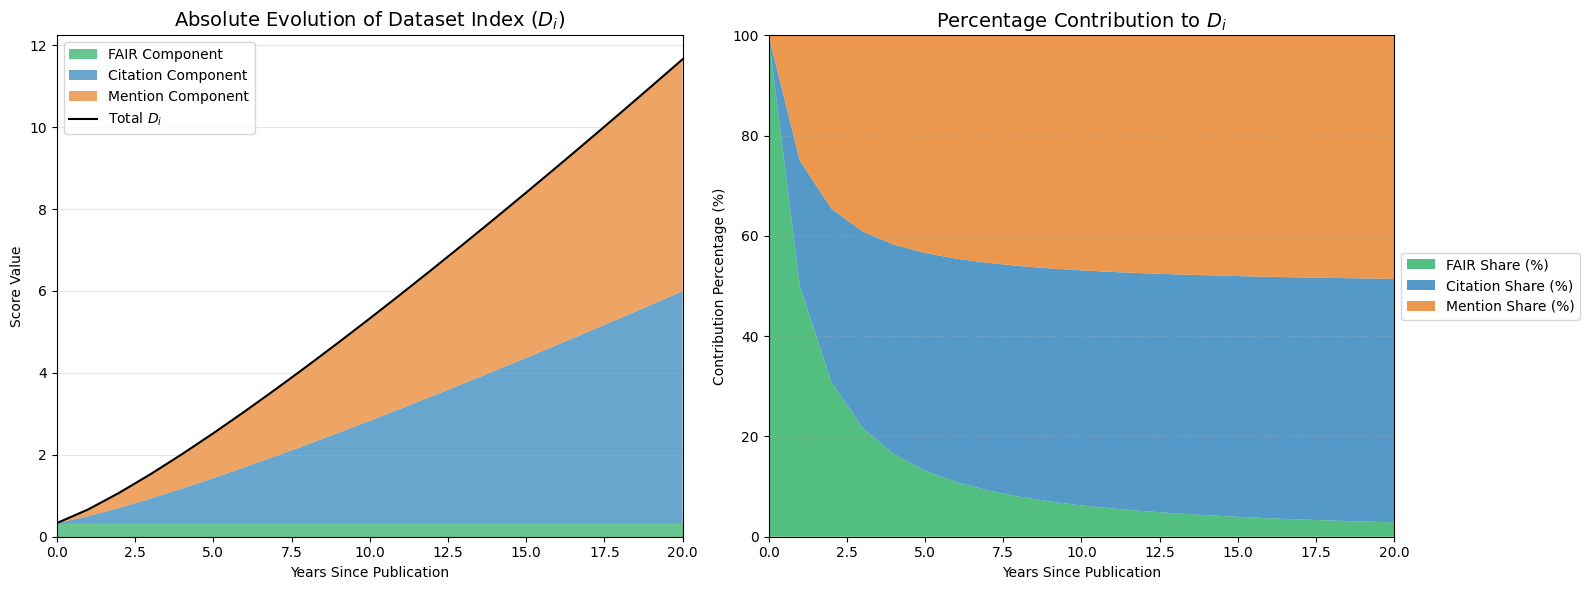

--- Dataset Index Evolution Summary ---


,Year,Di,F_pct,C_pct,M_pct
0,0,0.333333,100.000000,0.000000,0.000000
1,1,0.666667,50.000000,25.000000,25.000000
5,5,2.526624,13.192834,43.403583,43.403583
10,10,5.328152,6.256078,46.871961,46.871961
20,20,11.656918,2.859532,48.570234,48.570234


In [23]:
# 2. Simulation Logic
fi, ft, ctw, mtw = 50, 50, 2, 2
years = np.arange(0, 21)
history_years = []
results = []

for t in years:
    if t > 0:
        history_years.append(t) # 1 citation/mention received per year
    
    # Ages of all accumulated citations at current time t
    current_ages = [t - r for r in history_years]
    
    di, f_val, c_val, m_val = get_dataset_index(fi, current_ages, current_ages, ft, ctw, mtw)
    
    results.append({
        'Year': t,
        'Di': di,
        'F_val': f_val, 'C_val': c_val, 'M_val': m_val,
        'F_pct': (f_val / di) * 100,
        'C_pct': (c_val / di) * 100,
        'M_pct': (m_val / di) * 100
    })

df = pd.DataFrame(results)

# 3. Combined Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Absolute Score Growth
ax1.stackplot(df['Year'], df['F_val'], df['C_val'], df['M_val'], 
              labels=['FAIR Component', 'Citation Component', 'Mention Component'],
              colors=['#27ae60', '#2980b9', '#e67e22'], alpha=0.7)
ax1.plot(df['Year'], df['Di'], color='black', linewidth=1.5, label='Total $D_i$')
ax1.set_title('Absolute Evolution of Dataset Index ($D_i$)', fontsize=14)
ax1.set_xlabel('Years Since Publication')
ax1.set_ylabel('Score Value')
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlim(0, 20)

# Plot B: Percentage Contribution
ax2.stackplot(df['Year'], df['F_pct'], df['C_pct'], df['M_pct'], 
              labels=['FAIR Share (%)', 'Citation Share (%)', 'Mention Share (%)'],
              colors=['#27ae60', '#2980b9', '#e67e22'], alpha=0.8)
ax2.set_title('Percentage Contribution to $D_i$', fontsize=14)
ax2.set_xlabel('Years Since Publication')
ax2.set_ylabel('Contribution Percentage (%)')
ax2.set_ylim(0, 100)
ax2.set_xlim(0, 20)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Data Summary Table
print("--- Dataset Index Evolution Summary ---")
display(df[df['Year'].isin([0, 1, 5, 10, 20])][['Year', 'Di', 'F_pct', 'C_pct', 'M_pct']])

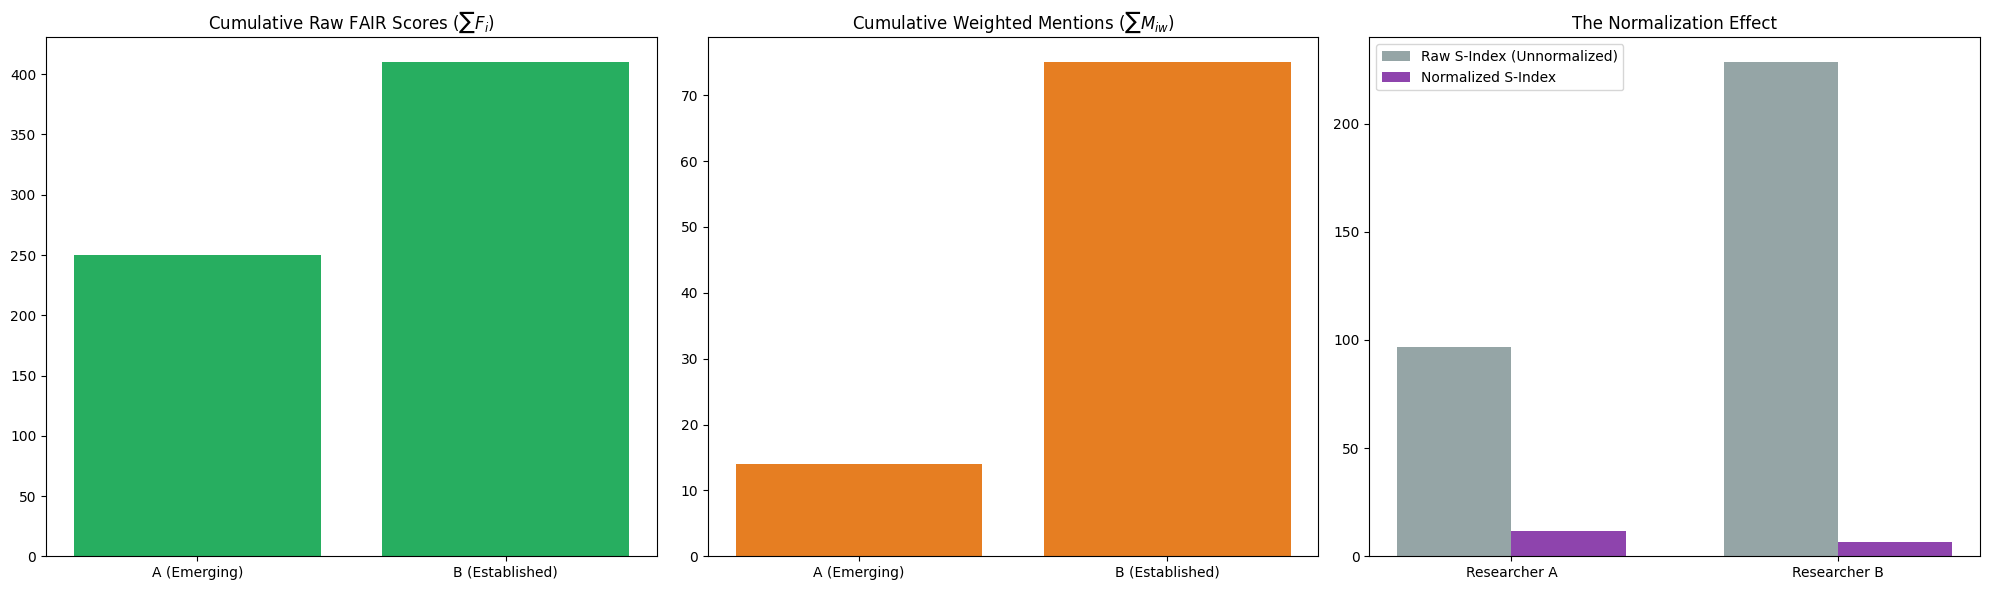

In [26]:
# 1. Calculation Functions
def get_di_normalized(fi, ciw, miw, ft, ctw, mtw):
    return (1/3) * (fi/ft + ciw/ctw + miw/mtw)

def get_di_raw(fi, ciw, miw):
    return (1/3) * (fi + ciw + miw)

# 2. Simulation Data
# Researcher A (Emerging Field): Lower raw scores, but high relative impact
# Researcher B (Established Field): High raw scores, but average relative impact
data_A = {'Fi': [50, 45, 60, 40, 55], 'Ciw': [5, 4, 8, 3, 6], 'Miw': [3, 2, 4, 2, 3],
          'FT': 30, 'CTW': 2, 'MTW': 1}

data_B = {'Fi': [80, 85, 75, 80, 90], 'Ciw': [40, 35, 30, 45, 50], 'Miw': [15, 12, 10, 18, 20],
          'FT': 75, 'CTW': 30, 'MTW': 10}

# S-Index Calculations
s_norm_A = sum(get_di_normalized(f, c, m, 30, 2, 1) for f, c, m in zip(data_A['Fi'], data_A['Ciw'], data_A['Miw']))
s_norm_B = sum(get_di_normalized(f, c, m, 75, 30, 10) for f, c, m in zip(data_B['Fi'], data_B['Ciw'], data_B['Miw']))

s_raw_A = sum(get_di_raw(f, c, m) for f, c, m in zip(data_A['Fi'], data_A['Ciw'], data_A['Miw']))
s_raw_B = sum(get_di_raw(f, c, m) for f, c, m in zip(data_B['Fi'], data_B['Ciw'], data_B['Miw']))

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: FAIR Comparison
axes[0].bar(['A (Emerging)', 'B (Established)'], [sum(data_A['Fi']), sum(data_B['Fi'])], color='#27ae60')
axes[0].set_title('Cumulative Raw FAIR Scores ($\sum F_i$)')

# Plot 2: Mention Comparison
axes[1].bar(['A (Emerging)', 'B (Established)'], [sum(data_A['Miw']), sum(data_B['Miw'])], color='#e67e22')
axes[1].set_title('Cumulative Weighted Mentions ($\sum M_{iw}$)')

# Plot 3: S-Index (Raw vs Normalized)
x = np.arange(2)
width = 0.35
axes[2].bar(x - width/2, [s_raw_A, s_raw_B], width, label='Raw S-Index (Unnormalized)', color='#95a5a6')
axes[2].bar(x + width/2, [s_norm_A, s_norm_B], width, label='Normalized S-Index', color='#8e44ad')
axes[2].set_title('The Normalization Effect')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Researcher A', 'Researcher B'])
axes[2].legend()

plt.tight_layout()
plt.show()

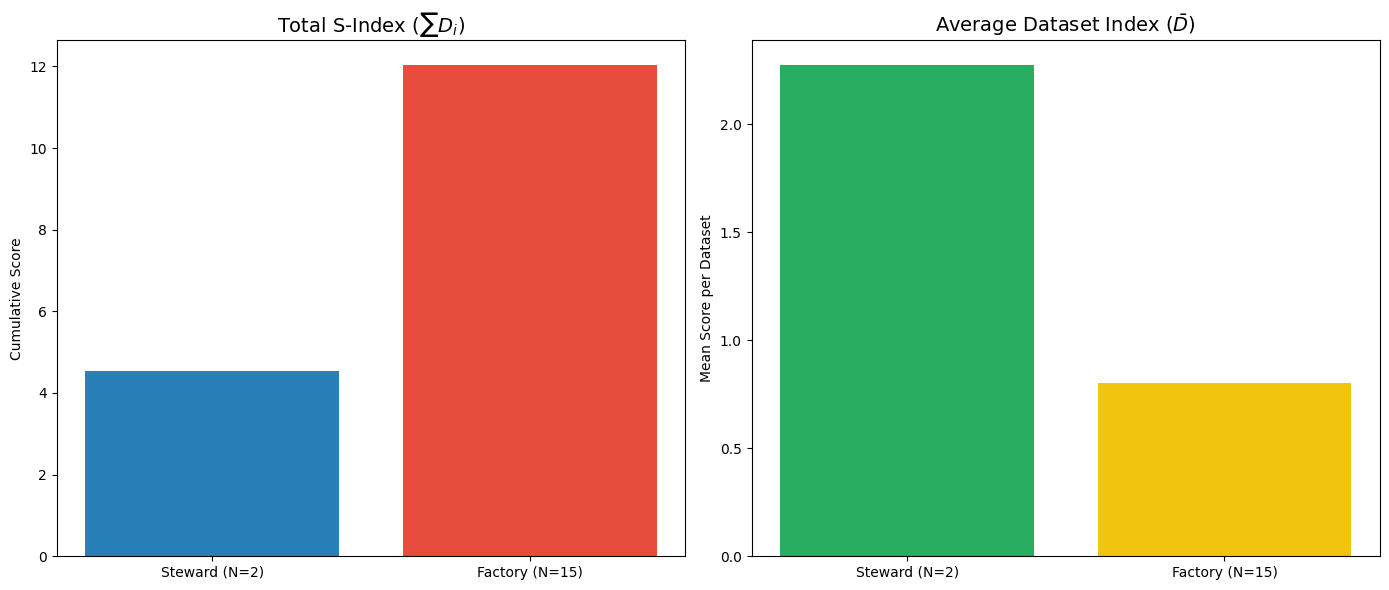

Steward (N=2):  S-Index = 4.55 | Average Di = 2.27
Factory (N=15): S-Index = 12.04 | Average Di = 0.80


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Framework Function
def get_di(fi, ciw, miw, ft=70, ctw=20, mtw=10):
    return (1/3) * (fi/ft + ciw/ctw + miw/mtw)

# 2. Adjusted Scenarios
# Steward (N=2): 2 very high impact datasets
data_A = {
    'Fi': [95, 90], 
    'Ciw': [60, 50], 
    'Miw': [30, 25]
}

# Factory (N=15): 15 datasets that are just below field medians
data_B = {
    'Fi': [60]*15, 
    'Ciw': [15]*15, 
    'Miw': [8]*15
}

# 3. Calculations
di_A = [get_di(f, c, m) for f, c, m in zip(data_A['Fi'], data_A['Ciw'], data_A['Miw'])]
di_B = [get_di(f, c, m) for f, c, m in zip(data_B['Fi'], data_B['Ciw'], data_B['Miw'])]

s_index_A, avg_di_A = sum(di_A), sum(di_A)/len(di_A)
s_index_B, avg_di_B = sum(di_B), sum(di_B)/len(di_B)

# 4. Visualization (using raw strings r'' for LaTeX)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(['Steward (N=2)', 'Factory (N=15)'], [s_index_A, s_index_B], color=['#2980b9', '#e74c3c'])
ax1.set_title(r'Total S-Index ($\sum D_i$)', fontsize=14)
ax1.set_ylabel('Cumulative Score')

ax2.bar(['Steward (N=2)', 'Factory (N=15)'], [avg_di_A, avg_di_B], color=['#27ae60', '#f1c40f'])
ax2.set_title(r'Average Dataset Index ($\bar{D}$)', fontsize=14)
ax2.set_ylabel('Mean Score per Dataset')

plt.tight_layout()
plt.show()

print(f"Steward (N=2):  S-Index = {s_index_A:.2f} | Average Di = {avg_di_A:.2f}")
print(f"Factory (N=15): S-Index = {s_index_B:.2f} | Average Di = {avg_di_B:.2f}")